In [1]:
from tensorflow_federated_variational_autoencoder.task import Net, get_processed_data

2025-04-29 14:33:59.136275: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-29 14:33:59.172257: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-29 14:33:59.193534: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-29 14:33:59.199867: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-29 14:33:59.226605: I tensorflow/core/platform/cpu_feature_guar

In [10]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
from datasets import Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

## Dataset Preparation

In [11]:
def load_data(dataset_path, batch_size=32, shuffle=True, target_dim=54):
    """
    Load data from a single dataset path, returning a dataloader with a 
    specific target dimension (54).
    
    Args:
        dataset_path: Path to the dataset file
        batch_size: Size of batches for the dataloader
        shuffle: Whether to shuffle the data
        target_dim: Target dimension for the dataset (default=54)
        
    Returns:
        dataloader: TensorFlow DataLoader for the dataset
        input_dim: Number of features in the dataset (will be 54)
    """
    # Get the processed data from the single path
    dataset = get_processed_data(dataset_path)
    
    # Record the original input dimension
    original_dim = dataset.shape[1]
    print(f"Dataset from {dataset_path} has original shape {dataset.shape}")
    
    # Handle dimension adjustment
    if original_dim < target_dim:
        # Pad with zeros to reach target dimension
        padding_needed = target_dim - original_dim
        padding = np.zeros((dataset.shape[0], padding_needed))
        dataset = np.hstack([dataset, padding])
        print(f"Padded dataset with {padding_needed} zero columns to reach dimension {target_dim}")
    elif original_dim > target_dim:
        # Truncate to target dimension
        dataset = dataset[:, :target_dim]
        print(f"Truncated dataset from dimension {original_dim} to {target_dim}")
    else:
        print(f"Dataset already has target dimension {target_dim}")
    
    # Confirm the new shape
    input_dim = dataset.shape[1]
    assert input_dim == target_dim, f"Expected dimension {target_dim}, got {input_dim}"
    print(f"Final dataset shape: {dataset.shape}")
    
    # Create DataFrame with default index and column handling
    df = pd.DataFrame(dataset)
    
    # Convert to HuggingFace dataset
    hf_dataset = Dataset.from_pandas(df)
    
    # Create TensorFlow dataset
    def create_tf_dataset(hf_dataset, batch_size=32, shuffle=False):
        # First, we need to convert the dataset to a format suitable for TensorFlow
        features_list = []
        
        # Process each sample in the dataset
        for sample in hf_dataset:
            # Each sample is a dict with keys like '0', '1', '2', ...
            # Convert to a list of feature values in correct order
            feature_values = [sample[str(i)] for i in range(len(sample))]
            features_list.append(feature_values)
        
        # Convert to NumPy array
        features_array = np.array(features_list, dtype=np.float32)
        
        # Create TensorFlow dataset
        tf_dataset = tf.data.Dataset.from_tensor_slices(features_array)
        
        # Apply shuffling if requested
        if shuffle:
            tf_dataset = tf_dataset.shuffle(buffer_size=len(features_array))
        
        # Batch the dataset
        tf_dataset = tf_dataset.batch(batch_size)
        
        return tf_dataset
    
    # Create TensorFlow dataset
    dataloader = create_tf_dataset(hf_dataset, batch_size=batch_size, shuffle=shuffle)
    
    # Verify the output shape
    for batch in dataloader.take(1):
        print(f"Batch shape: {batch.shape}")
        print(f"Feature dimension: {batch.shape[1]}")
        assert batch.shape[1] == target_dim, f"Expected batch feature dimension {target_dim}, got {batch.shape[1]}"
        break
    
    return dataloader, input_dim

## Testing the Model

In [12]:
class Net(keras.Model):
    def __init__(self, input_dim=None, latent_dim=10, hidden_dim=64):
        """
        VAE for tabular data with auto-detection of input dimension.
        
        Args:
            input_dim: Number of input features (can be None and determined on first call)
            latent_dim: Size of the latent space
            hidden_dim: Size of the hidden layers
        """
        super(Net, self).__init__()
        
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        self._is_built = False
        
        # Encoder
        self.encoder = keras.Sequential([
            keras.layers.Dense(hidden_dim, activation='relu'),
            keras.layers.Dense(hidden_dim, activation='relu')
        ])
        
        # Latent space
        self.fc_mu = keras.layers.Dense(latent_dim)
        self.fc_logvar = keras.layers.Dense(latent_dim)
        
        # Decoder will be built upon first call when input_dim is known
        if input_dim is not None:
            self.build_decoder(input_dim)
        else:
            self.decoder = None
    
    def build_decoder(self, input_dim):
        """Build the decoder once input dimension is known."""
        if self._is_built and self.input_dim == input_dim:
            # Already built with the same input dimension
            return
            
        print(f"Building decoder with input_dim={input_dim}")
        self.input_dim = input_dim
        self.decoder = keras.Sequential([
            keras.layers.Dense(self.hidden_dim, activation='relu'),
            keras.layers.Dense(self.hidden_dim, activation='relu'),
            keras.layers.Dense(input_dim)
        ])
        self._is_built = True
    
    def encode(self, x):
        """Encode input into latent representation."""
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        """Reparameterization trick."""
        std = tf.exp(0.5 * logvar)
        eps = tf.random.normal(shape=std.shape)
        z = mu + eps * std
        return z
    
    def decode(self, z):
        """Decode latent representation into reconstruction."""
        if self.decoder is None:
            raise ValueError("Decoder not built yet - model needs to be called with input data first")
        return self.decoder(z)
    
    def call(self, x):
        """Forward pass through the VAE."""
        # Auto-detect input dimension if not already determined
        if not self._is_built:
            input_dim = x.shape[1]
            print(f"Auto-detected input dimension: {input_dim}")
            self.build_decoder(input_dim)
        
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

    def build(self, input_shape):
        """
        Custom build method to ensure model is properly constructed.
        This will be called by Keras when using model.build().
        """
        # Input shape will be something like (None, input_dim)
        if len(input_shape) >= 2:
            input_dim = input_shape[1]
            if not self._is_built:
                print(f"Building model with input_shape={input_shape}, input_dim={input_dim}")
                self.build_decoder(input_dim)
        
        # Call the parent build method
        super(Net, self).build(input_shape)

In [13]:
def test(net, testloader):
    """Validate the VAE network on the entire test set and visualize worst reconstructions."""
    total, loss = 0, 0.0
    recon_total, kld_total = 0.0, 0.0
    
    # Lists to store all features, reconstructions and their errors
    all_features = []
    all_reconstructions = []
    all_recon_errors = []
    
    for batch in testloader:
        # Forward pass through the VAE
        recon_features, mu, logvar = net(batch)
        
        # Compute losses
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(recon_features - batch), axis=1))
        kld_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1)
        )
        batch_loss = recon_loss + 0.05 * kld_loss
        
        # Track statistics
        batch_size = tf.shape(batch)[0].numpy()
        loss += batch_loss.numpy() * batch_size
        recon_total += recon_loss.numpy() * batch_size
        kld_total += kld_loss.numpy() * batch_size
        total += batch_size
        
        # Calculate per-sample reconstruction error
        sample_recon_errors = tf.reduce_mean(tf.square(recon_features - batch), axis=1)
        
        # Store all samples
        for i in range(batch_size):
            all_features.append(batch[i].numpy())
            all_reconstructions.append(recon_features[i].numpy())
            all_recon_errors.append(sample_recon_errors[i].numpy())
    
    # Convert lists to numpy arrays
    all_recon_errors = np.array(all_recon_errors)
    
    # Get the indices of the 10 worst reconstructed samples
    worst10 = np.argsort(all_recon_errors)[-10:][::-1]
    
    # Calculate average reconstruction error
    avg_recon_error = np.mean(all_recon_errors)
    print(f"Average reconstruction error: {avg_recon_error:.4f}")
    
    avg_loss = loss / total
    avg_recon = recon_total / total
    avg_kld = kld_total / total
    
    print(f"Test Loss: {avg_loss:.4f}, Recon: {avg_recon:.4f}, KLD: {avg_kld:.4f}")
    
    return all_recon_errors

## Main Function

In [109]:
# Dataset paths and labels
dataset_paths = ["/workspace/datasets/cic-aa.normal.tls/*.json", "/workspace/datasets/cic-aa.adware.tls/*.json"]

# Path to the saved pre-trained model weights
pretrained_model_path = os.path.join("outputs", "2025-04-29", "19-39-14", "model_loss_0.559514_round_3.weights.h5")

#print("Loading and combining datasets...")

testloader1, input_dim1 = load_data(dataset_paths[0])
testloader2, input_dim2 = load_data(dataset_paths[1])

dataset shape=(31179, 28)
Normalized data shape:
(31179, 54)
Dataset from /workspace/datasets/cic-aa.normal.tls/*.json has original shape (31179, 54)
Dataset already has target dimension 54
Final dataset shape: (31179, 54)
Batch shape: (32, 54)
Feature dimension: 54
dataset shape=(7122, 28)
Normalized data shape:
(7122, 42)
Dataset from /workspace/datasets/cic-aa.adware.tls/*.json has original shape (7122, 42)
Padded dataset with 12 zero columns to reach dimension 54
Final dataset shape: (7122, 54)
Batch shape: (32, 54)
Feature dimension: 54


In [110]:
# First, recreate the model architecture
model1 = Net(input_dim=input_dim1, latent_dim=10, hidden_dim=64)

model1.build(input_shape=(None, input_dim1))  # Replace your_input_dim with actual dimension

# Load the weights
model1.load_weights(pretrained_model_path)

Building decoder with input_dim=54


In [111]:
# --- Testing ---
print("Starting testing...")
all_recon_errors1 = test(model1, testloader1)
all_recon_errors2 = test(model1, testloader2)

recons_df1 = pd.DataFrame({
        'error': all_recon_errors1,
        'y_true': np.zeros_like(all_recon_errors1)
    }).reset_index(drop=True)

recons_df2 = pd.DataFrame({
        'error': all_recon_errors2,
        'y_true': np.ones_like(all_recon_errors2)
    }).reset_index(drop=True)

print(f"Testing complete")

Starting testing...
Average reconstruction error: 0.1597
Test Loss: 8.6447, Recon: 8.6263, KLD: 0.3694
Average reconstruction error: 0.1786
Test Loss: 9.6696, Recon: 9.6453, KLD: 0.4848
Testing complete


In [112]:
combined_df = pd.concat([recons_df1, recons_df2], ignore_index=True)
print("Sample Reconstruction Data:")
print(combined_df.head()) # Optional: display some reconstruction results

Sample Reconstruction Data:
      error  y_true
0  0.149650     0.0
1  0.227227     0.0
2  0.113590     0.0
3  0.148677     0.0
4  0.258938     0.0


In [113]:
def thresholdTuning(df, iterations):
    
    thresh_df = {
        'threshold': [],
        'accuracy': [],
        'precision': [],
        'recall': []
    }
    
    for i in range(iterations):
        thresh_value = df['error'].quantile(i/iterations)
        preds = df['error'] > thresh_value
        cr = classification_report(df['y_true'], preds, output_dict=True)
        acc = cr['accuracy']
        prec = cr['macro avg']['precision']
        rc = cr['macro avg']['recall']
        
        thresh_df['threshold'].append(thresh_value)
        thresh_df['accuracy'].append(acc)
        thresh_df['precision'].append(prec)
        thresh_df['recall'].append(rc)
        
        print(f"Threshold: {thresh_value:.4f}\tAccuracy: {acc:.3f}\t\tPrecision: {prec:.3f}\tRecall Score: {rc:.3f}")
        
    return pd.DataFrame(thresh_df)
        
thresh_df = thresholdTuning(combined_df, 200)

Threshold: 0.0798	Accuracy: 0.186		Precision: 0.593	Recall Score: 0.500
Threshold: 0.0964	Accuracy: 0.191		Precision: 0.591	Recall Score: 0.503
Threshold: 0.0997	Accuracy: 0.196		Precision: 0.586	Recall Score: 0.506
Threshold: 0.1022	Accuracy: 0.200		Precision: 0.585	Recall Score: 0.508
Threshold: 0.1041	Accuracy: 0.205		Precision: 0.584	Recall Score: 0.511
Threshold: 0.1056	Accuracy: 0.210		Precision: 0.582	Recall Score: 0.513
Threshold: 0.1070	Accuracy: 0.214		Precision: 0.580	Recall Score: 0.515
Threshold: 0.1083	Accuracy: 0.219		Precision: 0.580	Recall Score: 0.518
Threshold: 0.1094	Accuracy: 0.223		Precision: 0.577	Recall Score: 0.520
Threshold: 0.1103	Accuracy: 0.228		Precision: 0.578	Recall Score: 0.522
Threshold: 0.1112	Accuracy: 0.232		Precision: 0.576	Recall Score: 0.524
Threshold: 0.1120	Accuracy: 0.236		Precision: 0.575	Recall Score: 0.526
Threshold: 0.1128	Accuracy: 0.241		Precision: 0.575	Recall Score: 0.528
Threshold: 0.1136	Accuracy: 0.245		Precision: 0.575	Recall Score

Threshold: 0.1671	Accuracy: 0.628		Precision: 0.556	Recall Score: 0.588
Threshold: 0.1677	Accuracy: 0.631		Precision: 0.556	Recall Score: 0.587
Threshold: 0.1682	Accuracy: 0.634		Precision: 0.556	Recall Score: 0.587
Threshold: 0.1687	Accuracy: 0.637		Precision: 0.556	Recall Score: 0.586
Threshold: 0.1693	Accuracy: 0.640		Precision: 0.556	Recall Score: 0.586
Threshold: 0.1699	Accuracy: 0.643		Precision: 0.557	Recall Score: 0.586
Threshold: 0.1706	Accuracy: 0.646		Precision: 0.556	Recall Score: 0.585
Threshold: 0.1712	Accuracy: 0.649		Precision: 0.557	Recall Score: 0.585
Threshold: 0.1719	Accuracy: 0.651		Precision: 0.557	Recall Score: 0.584
Threshold: 0.1724	Accuracy: 0.654		Precision: 0.556	Recall Score: 0.583
Threshold: 0.1731	Accuracy: 0.657		Precision: 0.557	Recall Score: 0.583
Threshold: 0.1738	Accuracy: 0.660		Precision: 0.557	Recall Score: 0.583
Threshold: 0.1745	Accuracy: 0.663		Precision: 0.557	Recall Score: 0.582
Threshold: 0.1751	Accuracy: 0.665		Precision: 0.557	Recall Score

In [114]:
threshold = thresh_df[thresh_df['recall'] == thresh_df['recall'].max()]['threshold'].values[0]
print(f"Threshold with Maximum Recall: {threshold:.6f}")

Threshold with Maximum Recall: 0.152627


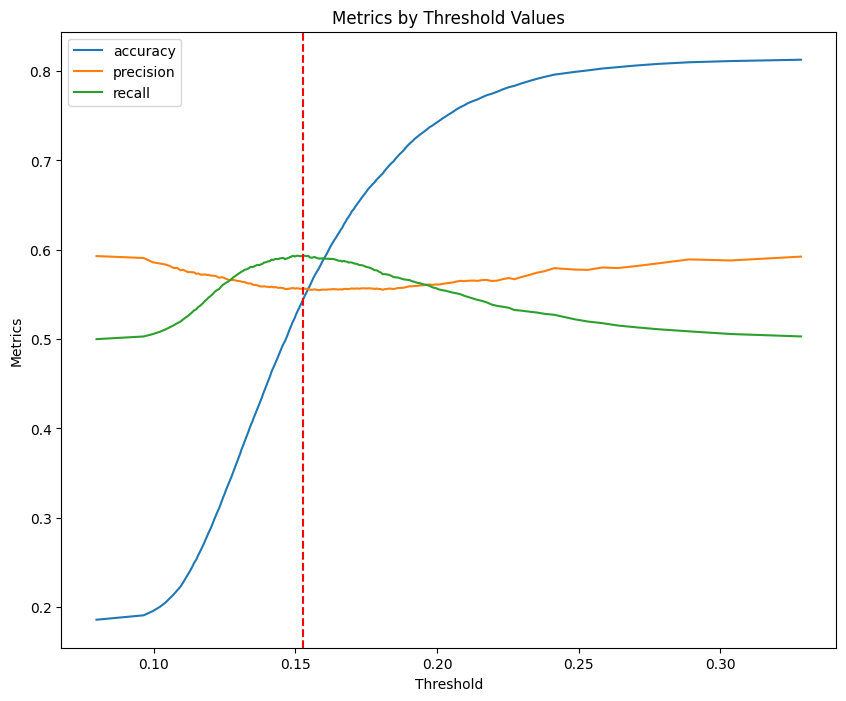

In [115]:
plt.figure(figsize=(10,8))
plt.plot(thresh_df['threshold'], thresh_df['accuracy'], label='accuracy')
plt.plot(thresh_df['threshold'], thresh_df['precision'], label='precision')
plt.plot(thresh_df['threshold'], thresh_df['recall'], label='recall')
plt.axvline(x=threshold, color='r', linestyle='dashed')
plt.xlabel('Threshold')
plt.ylabel('Metrics')
plt.title('Metrics by Threshold Values')
plt.legend()
plt.show()

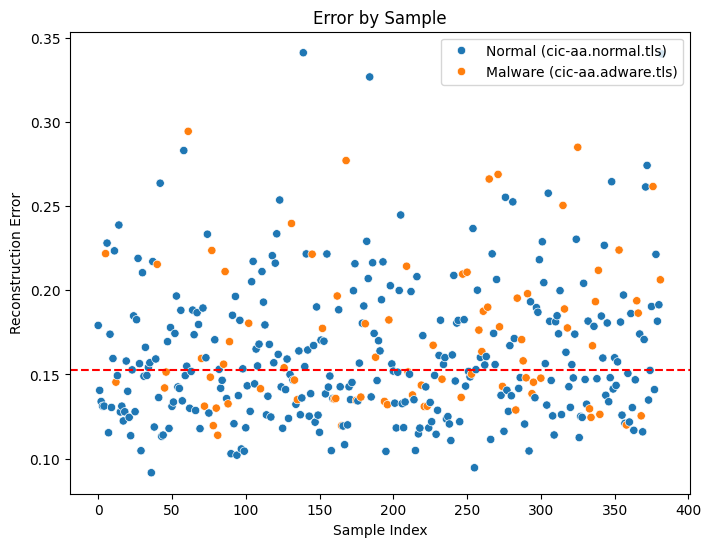

In [116]:
import re
extracted_names = []
for path in dataset_paths:
    dirname = os.path.dirname(path)
    last_folder = os.path.basename(dirname)
    extracted_names.append(last_folder)

temp = combined_df.sample(frac=0.01, random_state=42).reset_index(drop=True)
# Create a custom mapping for the legend labels
label_map = {0: f'Normal ({extracted_names[0]})', 1: f'Malware ({extracted_names[1]})'}  # Change these to your desired legend names
# Add a new column with mapped labels for the legend
temp['label'] = temp['y_true'].map(label_map)
plt.figure(figsize=(8,6))
#sns.scatterplot(data=temp, x=temp.index, y='error', hue='y_true')
sns.scatterplot(data=temp, x=temp.index, y='error', hue='label')
plt.axhline(y=threshold, color='r', linestyle='dashed')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Error by Sample')
plt.legend()
plt.show()